In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [148]:
orders = pd.read_csv('/Users/nitesh/Downloads/Task 1/olist_orders_dataset.csv')
items = pd.read_csv('/Users/nitesh/Downloads/Task 1/olist_order_items_dataset.csv')
customers = pd.read_csv('/Users/nitesh/Downloads/Task 1/olist_customers_dataset.csv')
products = pd.read_csv('/Users/nitesh/Downloads/Task 1/olist_products_dataset.csv')

In [4]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [6]:
orders.shape

(99441, 8)

In [7]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


### Initial Data Validation

In [8]:
print("Orders    :", orders.shape)
print("Items     :", items.shape)
print("Customers :", customers.shape)

Orders    : (99441, 8)
Items     : (112650, 7)
Customers : (99441, 5)


In [9]:
print(orders.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']


In [10]:
print(items.columns.tolist())

['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']


In [11]:
print(customers.columns.tolist())

['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']


In [12]:
print("\nOrders:")
print(orders.isnull().sum())


Orders:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


In [13]:
print(items.isnull().sum())

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64


In [14]:
print(customers.isnull().sum())

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64


In [15]:
print("Orders    :", orders.duplicated().sum())
print("Items     :", items.duplicated().sum())
print("Customers :", customers.duplicated().sum())

Orders    : 0
Items     : 0
Customers : 0


In [16]:
print(orders.dtypes)

order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object


In [17]:
print(items.dtypes)

order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object


In [18]:
print(customers.dtypes)

customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object


### Convert Date Columns to Datetime

In [19]:
order_date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

items_date_columns = [
    'shipping_limit_date'
]

In [20]:
orders[order_date_columns] = orders[order_date_columns].apply(
    pd.to_datetime,
    errors='coerce'
)

In [21]:
items[items_date_columns] = items[items_date_columns].apply(
    pd.to_datetime,
    errors='coerce'
)

In [22]:
print(orders.dtypes)

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [23]:
print(items.dtypes)

order_id                       object
order_item_id                   int64
product_id                     object
seller_id                      object
shipping_limit_date    datetime64[ns]
price                         float64
freight_value                 float64
dtype: object


### Analyze Missing Values by Order Status

In [25]:
print(orders['order_status'].value_counts())

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [26]:
missing_by_status = orders.groupby('order_status')[
    [
        'order_approved_at',
        'order_delivered_carrier_date',
        'order_delivered_customer_date'
    ]
].apply(lambda x: x.isnull().sum())

print(missing_by_status)

              order_approved_at  order_delivered_carrier_date  \
order_status                                                    
approved                      0                             2   
canceled                    141                           550   
created                       5                             5   
delivered                    14                             2   
invoiced                      0                           314   
processing                    0                           301   
shipped                       0                             0   
unavailable                   0                           609   

              order_delivered_customer_date  
order_status                                 
approved                                  2  
canceled                                619  
created                                   5  
delivered                                 8  
invoiced                                314  
processing                 

### Investigate Missing Dates in Delivered Orders

In [27]:
delivered_missing_dates = orders[
    (orders['order_status'] == 'delivered') &
    (
        orders['order_approved_at'].isnull() |
        orders['order_delivered_carrier_date'].isnull() |
        orders['order_delivered_customer_date'].isnull()
    )
]

In [28]:
print("Number of delivered orders with missing dates:",
      delivered_missing_dates.shape[0])

Number of delivered orders with missing dates: 23


In [29]:
print("\nMissing values in these records:")
print(delivered_missing_dates[
    [
        'order_id',
        'order_status',
        'order_purchase_timestamp',
        'order_approved_at',
        'order_delivered_carrier_date',
        'order_delivered_customer_date',
        'order_estimated_delivery_date'
    ]
].isnull().sum())


Missing values in these records:
order_id                          0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
dtype: int64


In [30]:
print("\nSample records:")
display(delivered_missing_dates[
    [
        'order_id',
        'order_status',
        'order_purchase_timestamp',
        'order_approved_at',
        'order_delivered_carrier_date',
        'order_delivered_customer_date',
        'order_estimated_delivery_date'
    ]
].head(20))


Sample records:


,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaT,2017-12-18
5323,e04abd8149ef81b95221e88f6ed9ab6a,delivered,2017-02-18 14:40:00,NaT,2017-02-23 12:04:47,2017-03-01 13:25:33,2017-03-17
16567,8a9adc69528e1001fc68dd0aaebbb54a,delivered,2017-02-18 12:45:31,NaT,2017-02-23 09:01:52,2017-03-02 10:05:06,2017-03-21
19031,7013bcfc1c97fe719a7b5e05e61c12db,delivered,2017-02-18 13:29:47,NaT,2017-02-22 16:25:25,2017-03-01 08:07:38,2017-03-17
20618,f5dd62b788049ad9fc0526e3ad11a097,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaT,2018-07-16
22663,5cf925b116421afa85ee25e99b4c34fb,delivered,2017-02-18 16:48:35,NaT,2017-02-22 11:23:10,2017-03-09 07:28:47,2017-03-31
23156,12a95a3c06dbaec84bcfb0e2da5d228a,delivered,2017-02-17 13:05:55,NaT,2017-02-22 11:23:11,2017-03-02 11:09:19,2017-03-20
26800,c1d4211b3dae76144deccd6c74144a88,delivered,2017-01-19 12:48:08,NaT,2017-01-25 14:56:50,2017-01-30 18:16:01,2017-03-01
38290,d69e5d356402adc8cf17e08b5033acfb,delivered,2017-02-19 01:28:47,NaT,2017-02-23 03:11:48,2017-03-02 03:41:58,2017-03-27
39334,d77031d6a3c8a52f019764e68f211c69,delivered,2017-02-18 11:04:19,NaT,2017-02-23 07:23:36,2017-03-02 16:15:23,2017-03-22


### Missing Value Percentage

In [31]:
missing_summary = pd.DataFrame({
    'Missing_Count': orders.isnull().sum(),
    'Missing_Percentage': (orders.isnull().sum() / len(orders) * 100).round(2)
})

print(missing_summary)

                               Missing_Count  Missing_Percentage
order_id                                   0                0.00
customer_id                                0                0.00
order_status                               0                0.00
order_purchase_timestamp                   0                0.00
order_approved_at                        160                0.16
order_delivered_carrier_date            1783                1.79
order_delivered_customer_date           2965                2.98
order_estimated_delivery_date              0                0.00


### Check chronological consistency of order dates

In [32]:
date_issues = {
    'approved_before_purchase': (
        orders['order_approved_at'].notna() &
        (orders['order_approved_at'] < orders['order_purchase_timestamp'])
    ).sum(),

    'carrier_before_purchase': (
        orders['order_delivered_carrier_date'].notna() &
        (orders['order_delivered_carrier_date'] < orders['order_purchase_timestamp'])
    ).sum(),

    'customer_delivery_before_purchase': (
        orders['order_delivered_customer_date'].notna() &
        (orders['order_delivered_customer_date'] < orders['order_purchase_timestamp'])
    ).sum(),

    'customer_delivery_before_carrier': (
        orders['order_delivered_customer_date'].notna() &
        orders['order_delivered_carrier_date'].notna() &
        (orders['order_delivered_customer_date'] < orders['order_delivered_carrier_date'])
    ).sum()
}

print("Date consistency issues:")
for issue, count in date_issues.items():
    print(f"{issue}: {count}")

Date consistency issues:
approved_before_purchase: 0
carrier_before_purchase: 166
customer_delivery_before_purchase: 0
customer_delivery_before_carrier: 23


### Inspect carrier date before purchase date

In [33]:
carrier_date_issues = orders[
    orders['order_delivered_carrier_date'].notna() &
    (orders['order_delivered_carrier_date'] < orders['order_purchase_timestamp'])
]

print("Number of carrier date issues:", carrier_date_issues.shape[0])

display(
    carrier_date_issues[
        [
            'order_id',
            'order_status',
            'order_purchase_timestamp',
            'order_approved_at',
            'order_delivered_carrier_date',
            'order_delivered_customer_date',
            'order_estimated_delivery_date'
        ]
    ].head(20)
)

Number of carrier date issues: 166


,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
615,b9afddbdcfadc9a87b41a83271c3e888,delivered,2018-08-16 13:50:48,2018-08-16 14:05:13,2018-08-16 13:27:00,2018-08-24 14:58:37,2018-09-04
1111,ad133696906f6a78826daa0911b7daec,delivered,2018-06-15 15:41:22,2018-06-15 16:19:23,2018-06-15 14:52:00,2018-06-22 18:09:37,2018-07-18
1329,74e033208dc13a7b8127eb8e73d09b76,delivered,2018-05-02 10:48:44,2018-05-02 11:13:45,2018-05-02 09:49:00,2018-05-07 23:06:36,2018-05-29
1372,a6b58794fd2ba533359a76c08df576e3,delivered,2018-05-14 15:18:23,2018-05-14 15:33:35,2018-05-14 13:46:00,2018-05-19 19:33:32,2018-06-08
1864,5792e0b1c8c8a2bf53af468c9a422c88,delivered,2018-07-26 13:25:14,2018-07-26 13:35:14,2018-07-26 12:42:00,2018-07-30 14:45:02,2018-08-09
2760,c3eb293fd154223498b6551a728203e8,delivered,2018-07-19 14:06:04,2018-07-19 14:22:51,2018-07-19 13:49:00,2018-07-24 19:35:36,2018-08-06
3473,b0c2a7d04b165525254254a728c50a4e,delivered,2018-06-07 13:28:30,2018-06-07 13:57:22,2018-06-07 13:22:00,2018-06-21 17:36:43,2018-07-04
3661,2033a4586b5bec3229ebc1675a8ae092,delivered,2018-06-12 10:10:25,2018-06-12 10:39:59,2018-06-12 10:09:00,2018-06-19 14:08:27,2018-07-19
4114,08adcddad19d3acf37d1fa01cb9ded1e,delivered,2018-06-27 11:16:44,2018-06-27 11:30:56,2018-06-27 10:57:00,2018-06-29 17:39:53,2018-07-18
4159,dee6298ce7d1fb2645141ef9972157aa,shipped,2018-04-30 14:06:12,2018-04-30 14:15:24,2018-04-30 12:59:00,NaT,2018-05-28


### Quantify carrier date anomalies

In [34]:
carrier_date_issues = orders[
    orders['order_delivered_carrier_date'].notna() &
    (orders['order_delivered_carrier_date'] < orders['order_purchase_timestamp'])
].copy()

carrier_date_issues['time_difference'] = (
    carrier_date_issues['order_purchase_timestamp']
    - carrier_date_issues['order_delivered_carrier_date']
)

print("Number of issues:", len(carrier_date_issues))

print("\nTime difference statistics:")
print(carrier_date_issues['time_difference'].describe())

print("\nTime difference in hours:")
print(
    carrier_date_issues['time_difference']
    .dt.total_seconds()
    .div(3600)
    .describe()
)

print("\nIssues by order status:")
print(carrier_date_issues['order_status'].value_counts())

Number of issues: 166

Time difference statistics:
count                           166
mean      1 days 02:02:22.120481927
std      13 days 06:55:25.842359086
min                 0 days 00:00:24
25%                 0 days 00:14:04
50%          0 days 00:35:59.500000
75%                 0 days 01:01:03
max               171 days 05:05:53
Name: time_difference, dtype: object

Time difference in hours:
count     166.000000
mean       26.039478
std       318.923845
min         0.006667
25%         0.234444
50%         0.599861
75%         1.017500
max      4109.098056
Name: time_difference, dtype: float64

Issues by order status:
order_status
delivered    165
shipped        1
Name: count, dtype: int64


### Inspect the largest carrier-date anomalies

In [36]:
carrier_date_issues['difference_hours'] = (
    carrier_date_issues['time_difference']
    .dt.total_seconds() / 3600
)

largest_carrier_issues = carrier_date_issues.sort_values(
    'difference_hours',
    ascending=False
)

display(
    largest_carrier_issues[
        [
            'order_id',
            'order_status',
            'order_purchase_timestamp',
            'order_approved_at',
            'order_delivered_carrier_date',
            'order_delivered_customer_date',
            'order_estimated_delivery_date',
            'difference_hours'
        ]
    ].head()
)

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,difference_hours
25883,7c48bb55e8e4f7e56d412e9653db37bc,delivered,2018-07-16 18:40:53,2018-07-16 18:50:22,2018-01-26 13:35:00,2018-07-23 20:04:45,2018-08-07,4109.098056
83321,4021cd7611d6d9ce5ffcd24817fc374f,delivered,2018-08-18 11:49:40,2018-08-18 12:10:30,2018-08-14 06:22:00,2018-08-29 04:41:53,2018-08-30,101.461111
67844,db090a16182b263b1e896bb26c6f66cf,delivered,2018-07-13 16:14:08,2018-07-13 16:44:09,2018-07-13 13:59:00,2018-07-27 11:34:31,2018-08-06,2.252222
65452,9711d975b961355b4b5d636857e48498,delivered,2018-06-13 15:23:50,2018-06-13 15:38:18,2018-06-13 13:15:00,2018-06-26 00:33:48,2018-06-29,2.147222
79401,89d32b64af005178b318f76cd60f2c3c,delivered,2018-07-06 11:54:40,2018-07-06 12:11:05,2018-07-06 09:48:00,2018-07-10 11:44:45,2018-07-27,2.111111


### Categorize carrier-date anomalies by severity

In [37]:
carrier_date_issues['difference_hours'] = (
    carrier_date_issues['time_difference'].dt.total_seconds() / 3600
)

severity = pd.cut(
    carrier_date_issues['difference_hours'],
    bins=[0, 1, 24, 24 * 7, float('inf')],
    labels=[
        'Less than 1 hour',
        '1 to 24 hours',
        '1 to 7 days',
        'More than 7 days'
],
    right=False
)

print("Severity of carrier-date anomalies:")
print(severity.value_counts().sort_index())

print("\nPercentage:")
print(
    (severity.value_counts(normalize=True).sort_index() * 100)
    .round(2)
)

Severity of carrier-date anomalies:
difference_hours
Less than 1 hour    121
1 to 24 hours        43
1 to 7 days           1
More than 7 days      1
Name: count, dtype: int64

Percentage:
difference_hours
Less than 1 hour    72.89
1 to 24 hours       25.90
1 to 7 days          0.60
More than 7 days     0.60
Name: proportion, dtype: float64


### Inspect severe carrier-date anomalies

In [38]:
severe_carrier_issues = carrier_date_issues[
    carrier_date_issues['difference_hours'] > 24 * 7
].sort_values(
    'difference_hours',
    ascending=False
)

print("Severe anomalies:", severe_carrier_issues.shape[0])

display(
    severe_carrier_issues[
        [
            'order_id',
            'order_status',
            'order_purchase_timestamp',
            'order_approved_at',
            'order_delivered_carrier_date',
            'order_delivered_customer_date',
            'order_estimated_delivery_date',
            'difference_hours'
        ]
    ]
)

Severe anomalies: 1


,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,difference_hours
25883,7c48bb55e8e4f7e56d412e9653db37bc,delivered,2018-07-16 18:40:53,2018-07-16 18:50:22,2018-01-26 13:35:00,2018-07-23 20:04:45,2018-08-07,4109.098056


### handle these anomalies

In [39]:
print("\nTotal Orders:", len(orders))


Total Orders: 99441


In [40]:
print("\nMissing Values:")
print(
    orders[
        [
            'order_approved_at',
            'order_delivered_carrier_date',
            'order_delivered_customer_date',
            'order_estimated_delivery_date'
        ]
    ].isnull().sum()
)


Missing Values:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


In [42]:
approved_before_purchase = (
    orders['order_approved_at'] < orders['order_purchase_timestamp']
)

carrier_before_purchase = (
    orders['order_delivered_carrier_date'] < orders['order_purchase_timestamp']
)

customer_delivery_before_purchase = (
    orders['order_delivered_customer_date'] < orders['order_purchase_timestamp']
)

customer_delivery_before_carrier = (
    orders['order_delivered_customer_date'] < orders['order_delivered_carrier_date']
)

In [43]:
print("\nDate Consistency Issues:")
print("Approved before purchase:", approved_before_purchase.sum())
print("Carrier before purchase:", carrier_before_purchase.sum())
print("Customer delivery before purchase:", customer_delivery_before_purchase.sum())
print("Customer delivery before carrier:", customer_delivery_before_carrier.sum())


Date Consistency Issues:
Approved before purchase: 0
Carrier before purchase: 166
Customer delivery before purchase: 0
Customer delivery before carrier: 23


In [44]:
missing_analysis = orders.groupby('order_status')[
    [
        'order_approved_at',
        'order_delivered_carrier_date',
        'order_delivered_customer_date'
    ]
].apply(lambda x: x.isnull().sum())

print(missing_analysis)

              order_approved_at  order_delivered_carrier_date  \
order_status                                                    
approved                      0                             2   
canceled                    141                           550   
created                       5                             5   
delivered                    14                             2   
invoiced                      0                           314   
processing                    0                           301   
shipped                       0                             0   
unavailable                   0                           609   

              order_delivered_customer_date  
order_status                                 
approved                                  2  
canceled                                619  
created                                   5  
delivered                                 8  
invoiced                                314  
processing                 

### Isolate the genuinely problematic records

In [45]:
# 1. Delivered orders missing approval date
delivered_missing_approval = orders[
    (orders['order_status'] == 'delivered') &
    (orders['order_approved_at'].isnull())
]

# 2. Delivered orders missing carrier date
delivered_missing_carrier = orders[
    (orders['order_status'] == 'delivered') &
    (orders['order_delivered_carrier_date'].isnull())
]

# 3. Delivered orders missing customer delivery date
delivered_missing_customer = orders[
    (orders['order_status'] == 'delivered') &
    (orders['order_delivered_customer_date'].isnull())
]

print("Delivered orders missing approval date:", len(delivered_missing_approval))
print("Delivered orders missing carrier date:", len(delivered_missing_carrier))
print("Delivered orders missing customer delivery date:", len(delivered_missing_customer))

Delivered orders missing approval date: 14
Delivered orders missing carrier date: 2
Delivered orders missing customer delivery date: 8


In [46]:
problematic_missing_dates = pd.concat([
    delivered_missing_approval,
    delivered_missing_carrier,
    delivered_missing_customer
]).drop_duplicates(subset='order_id')

print("Total unique problematic records:", len(problematic_missing_dates))

display(
    problematic_missing_dates[
        [
            'order_id',
            'order_status',
            'order_purchase_timestamp',
            'order_approved_at',
            'order_delivered_carrier_date',
            'order_delivered_customer_date',
            'order_estimated_delivery_date'
        ]
    ]
)

Total unique problematic records: 23


,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
5323,e04abd8149ef81b95221e88f6ed9ab6a,delivered,2017-02-18 14:40:00,NaT,2017-02-23 12:04:47,2017-03-01 13:25:33,2017-03-17
16567,8a9adc69528e1001fc68dd0aaebbb54a,delivered,2017-02-18 12:45:31,NaT,2017-02-23 09:01:52,2017-03-02 10:05:06,2017-03-21
19031,7013bcfc1c97fe719a7b5e05e61c12db,delivered,2017-02-18 13:29:47,NaT,2017-02-22 16:25:25,2017-03-01 08:07:38,2017-03-17
22663,5cf925b116421afa85ee25e99b4c34fb,delivered,2017-02-18 16:48:35,NaT,2017-02-22 11:23:10,2017-03-09 07:28:47,2017-03-31
23156,12a95a3c06dbaec84bcfb0e2da5d228a,delivered,2017-02-17 13:05:55,NaT,2017-02-22 11:23:11,2017-03-02 11:09:19,2017-03-20
26800,c1d4211b3dae76144deccd6c74144a88,delivered,2017-01-19 12:48:08,NaT,2017-01-25 14:56:50,2017-01-30 18:16:01,2017-03-01
38290,d69e5d356402adc8cf17e08b5033acfb,delivered,2017-02-19 01:28:47,NaT,2017-02-23 03:11:48,2017-03-02 03:41:58,2017-03-27
39334,d77031d6a3c8a52f019764e68f211c69,delivered,2017-02-18 11:04:19,NaT,2017-02-23 07:23:36,2017-03-02 16:15:23,2017-03-22
48401,7002a78c79c519ac54022d4f8a65e6e8,delivered,2017-01-19 22:26:59,NaT,2017-01-27 11:08:05,2017-02-06 14:22:19,2017-03-16
61743,2eecb0d85f281280f79fa00f9cec1a95,delivered,2017-02-17 17:21:55,NaT,2017-02-22 11:42:51,2017-03-03 12:16:03,2017-03-20


In [47]:
# Check how many missing date fields each problematic order has
problematic_missing_dates['missing_date_count'] = (
    problematic_missing_dates[
        [
            'order_approved_at',
            'order_delivered_carrier_date',
            'order_delivered_customer_date'
        ]
    ].isnull().sum(axis=1)
)

print("Records with multiple missing dates:")
display(
    problematic_missing_dates[
        problematic_missing_dates['missing_date_count'] > 1
    ][
        [
            'order_id',
            'order_status',
            'order_approved_at',
            'order_delivered_carrier_date',
            'order_delivered_customer_date',
            'missing_date_count'
        ]
    ]
)

Records with multiple missing dates:


,order_id,order_status,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,missing_date_count
92643,2d858f451373b04fb5c984a1cc2defaf,delivered,2017-05-25 23:30:16,NaT,NaT,2


In [48]:
display(
    problematic_missing_dates[
        [
            'order_id',
            'order_status',
            'order_purchase_timestamp',
            'order_approved_at',
            'order_delivered_carrier_date',
            'order_delivered_customer_date',
            'order_estimated_delivery_date'
        ]
    ].sort_values('order_id')
)

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
82868,0d3268bad9b086af767785e3f0fc0133,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaT,2018-07-24
23156,12a95a3c06dbaec84bcfb0e2da5d228a,delivered,2017-02-17 13:05:55,NaT,2017-02-22 11:23:11,2017-03-02 11:09:19,2017-03-20
98038,20edc82cf5400ce95e1afacc25798b31,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaT,2018-07-19
73222,2aa91108853cecb43c84a5dc5b277475,delivered,2017-09-29 08:52:58,2017-09-29 09:07:16,NaT,2017-11-20 19:44:47,2017-11-14
84999,2babbb4b15e6d2dfe95e2de765c97bce,delivered,2017-02-18 17:15:03,NaT,2017-02-22 11:23:11,2017-03-03 18:43:43,2017-03-31
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaT,2017-12-18
92643,2d858f451373b04fb5c984a1cc2defaf,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaT,NaT,2017-06-23
43834,2ebdfc4f15f23b91474edf87475f108e,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaT,2018-07-30
61743,2eecb0d85f281280f79fa00f9cec1a95,delivered,2017-02-17 17:21:55,NaT,2017-02-22 11:42:51,2017-03-03 12:16:03,2017-03-20
72407,3c0b8706b065f9919d0505d3b3343881,delivered,2017-02-17 15:53:27,NaT,2017-02-22 11:31:30,2017-03-03 11:47:47,2017-03-23


### Inspect all problematic delivered orders

In [49]:
problematic_delivered = orders[
    (orders['order_status'] == 'delivered') &
    (
        orders['order_approved_at'].isnull() |
        orders['order_delivered_carrier_date'].isnull() |
        orders['order_delivered_customer_date'].isnull()
    )
]

print("Total problematic delivered orders:", len(problematic_delivered))

display(
    problematic_delivered[
        [
            'order_id',
            'order_status',
            'order_purchase_timestamp',
            'order_approved_at',
            'order_delivered_carrier_date',
            'order_delivered_customer_date',
            'order_estimated_delivery_date'
        ]
    ]
)

Total problematic delivered orders: 23


,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaT,2017-12-18
5323,e04abd8149ef81b95221e88f6ed9ab6a,delivered,2017-02-18 14:40:00,NaT,2017-02-23 12:04:47,2017-03-01 13:25:33,2017-03-17
16567,8a9adc69528e1001fc68dd0aaebbb54a,delivered,2017-02-18 12:45:31,NaT,2017-02-23 09:01:52,2017-03-02 10:05:06,2017-03-21
19031,7013bcfc1c97fe719a7b5e05e61c12db,delivered,2017-02-18 13:29:47,NaT,2017-02-22 16:25:25,2017-03-01 08:07:38,2017-03-17
20618,f5dd62b788049ad9fc0526e3ad11a097,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaT,2018-07-16
22663,5cf925b116421afa85ee25e99b4c34fb,delivered,2017-02-18 16:48:35,NaT,2017-02-22 11:23:10,2017-03-09 07:28:47,2017-03-31
23156,12a95a3c06dbaec84bcfb0e2da5d228a,delivered,2017-02-17 13:05:55,NaT,2017-02-22 11:23:11,2017-03-02 11:09:19,2017-03-20
26800,c1d4211b3dae76144deccd6c74144a88,delivered,2017-01-19 12:48:08,NaT,2017-01-25 14:56:50,2017-01-30 18:16:01,2017-03-01
38290,d69e5d356402adc8cf17e08b5033acfb,delivered,2017-02-19 01:28:47,NaT,2017-02-23 03:11:48,2017-03-02 03:41:58,2017-03-27
39334,d77031d6a3c8a52f019764e68f211c69,delivered,2017-02-18 11:04:19,NaT,2017-02-23 07:23:36,2017-03-02 16:15:23,2017-03-22


In [50]:
print("Missing values among 23 problematic delivered orders:\n")

print(
    problematic_delivered[
        [
            'order_approved_at',
            'order_delivered_carrier_date',
            'order_delivered_customer_date'
        ]
    ].isnull().sum()
)

Missing values among 23 problematic delivered orders:

order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
dtype: int64


In [51]:
print("\nRecords with multiple missing dates:")

multiple_missing = problematic_delivered[
    problematic_delivered[
        [
            'order_approved_at',
            'order_delivered_carrier_date',
            'order_delivered_customer_date'
        ]
    ].isnull().sum(axis=1) > 1
]

print("Count:", len(multiple_missing))

display(multiple_missing[
    [
        'order_id',
        'order_purchase_timestamp',
        'order_approved_at',
        'order_delivered_carrier_date',
        'order_delivered_customer_date'
    ]
])


Records with multiple missing dates:
Count: 1


,order_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date
92643,2d858f451373b04fb5c984a1cc2defaf,2017-05-25 23:22:43,2017-05-25 23:30:16,NaT,NaT


In [52]:
display(
    problematic_delivered[
        [
            'order_id',
            'order_purchase_timestamp',
            'order_approved_at',
            'order_delivered_carrier_date',
            'order_delivered_customer_date',
            'order_estimated_delivery_date'
        ]
    ].sort_values('order_id')
)

,order_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
82868,0d3268bad9b086af767785e3f0fc0133,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaT,2018-07-24
23156,12a95a3c06dbaec84bcfb0e2da5d228a,2017-02-17 13:05:55,NaT,2017-02-22 11:23:11,2017-03-02 11:09:19,2017-03-20
98038,20edc82cf5400ce95e1afacc25798b31,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaT,2018-07-19
73222,2aa91108853cecb43c84a5dc5b277475,2017-09-29 08:52:58,2017-09-29 09:07:16,NaT,2017-11-20 19:44:47,2017-11-14
84999,2babbb4b15e6d2dfe95e2de765c97bce,2017-02-18 17:15:03,NaT,2017-02-22 11:23:11,2017-03-03 18:43:43,2017-03-31
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaT,2017-12-18
92643,2d858f451373b04fb5c984a1cc2defaf,2017-05-25 23:22:43,2017-05-25 23:30:16,NaT,NaT,2017-06-23
43834,2ebdfc4f15f23b91474edf87475f108e,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaT,2018-07-30
61743,2eecb0d85f281280f79fa00f9cec1a95,2017-02-17 17:21:55,NaT,2017-02-22 11:42:51,2017-03-03 12:16:03,2017-03-20
72407,3c0b8706b065f9919d0505d3b3343881,2017-02-17 15:53:27,NaT,2017-02-22 11:31:30,2017-03-03 11:47:47,2017-03-23


### Create a clean dataset

Create dataset for delivery-time analysis

In [53]:
delivery_analysis = orders[
    (orders['order_status'] == 'delivered') &
    (orders['order_purchase_timestamp'].notna()) &
    (orders['order_delivered_carrier_date'].notna()) &
    (orders['order_delivered_customer_date'].notna())
].copy()

print("Total delivered orders:", 
      (orders['order_status'] == 'delivered').sum())

print("Orders available for delivery-time analysis:", 
      len(delivery_analysis))

print("Excluded due to missing delivery dates:", 
      (orders['order_status'] == 'delivered').sum() - len(delivery_analysis))

Total delivered orders: 96478
Orders available for delivery-time analysis: 96469
Excluded due to missing delivery dates: 9


In [54]:
# Identify date consistency anomalies
delivery_analysis['carrier_before_purchase'] = (
    delivery_analysis['order_delivered_carrier_date']
    < delivery_analysis['order_purchase_timestamp']
)

delivery_analysis['customer_before_carrier'] = (
    delivery_analysis['order_delivered_customer_date']
    < delivery_analysis['order_delivered_carrier_date']
)

print("Carrier before purchase:",
      delivery_analysis['carrier_before_purchase'].sum())

print("Customer delivery before carrier:",
      delivery_analysis['customer_before_carrier'].sum())

Carrier before purchase: 165
Customer delivery before carrier: 23


In [55]:
# Remove date-consistency anomalies for delivery analysis

clean_delivery_analysis = delivery_analysis[
    (~delivery_analysis['carrier_before_purchase']) &
    (~delivery_analysis['customer_before_carrier'])
].copy()

print("Original delivery-analysis records:", len(delivery_analysis))
print("Clean delivery-analysis records:", len(clean_delivery_analysis))
print("Excluded date-anomaly records:",
      len(delivery_analysis) - len(clean_delivery_analysis))

Original delivery-analysis records: 96469
Clean delivery-analysis records: 96281
Excluded date-anomaly records: 188


In [56]:
# Delivery time in days
clean_delivery_analysis['delivery_time_days'] = (
    clean_delivery_analysis['order_delivered_customer_date']
    - clean_delivery_analysis['order_purchase_timestamp']
).dt.total_seconds() / (24 * 3600)

print("Delivery Time Statistics:")
print(clean_delivery_analysis['delivery_time_days'].describe())

Delivery Time Statistics:
count    96281.000000
mean        12.568101
std          9.549581
min          0.533414
25%          6.775822
50%         10.227187
75%         15.732361
max        209.628611
Name: delivery_time_days, dtype: float64


In [57]:
# checking unusual long deliveries
print("\nVery Long Deliveries:")
print(
    clean_delivery_analysis[
        clean_delivery_analysis['delivery_time_days'] > 30
    ][[
        'order_id',
        'order_purchase_timestamp',
        'order_delivered_customer_date',
        'delivery_time_days'
    ]]
)


Very Long Deliveries:
                               order_id order_purchase_timestamp  \
29     ecab90c9933c58908d3d6add7c6f5ae3      2018-02-25 13:50:30   
35     8563039e855156e48fccee4d611a3196      2018-02-17 15:59:46   
41     6ea2f835b4556291ffdc53fa0b3b95e8      2017-11-24 21:27:48   
97     6a0a8bfbbe700284feb0845d95e0867f      2017-11-22 11:32:22   
110    9d531c565e28c3e0d756192f84d8731f      2017-11-28 21:00:44   
...                                 ...                      ...   
99121  25f6cb0e242a4c0bacc239397614422e      2017-11-20 12:50:49   
99266  76a948cd55bf22799753720d4545dd2d      2018-01-30 02:41:30   
99279  4cf09d9e5ebbe0f91ddd7bf9aae891cd      2018-07-19 08:37:26   
99423  38e9133ce29f6bbe35aed9c3863dce01      2017-10-12 20:54:11   
99432  cfa78b997e329a5295b4ee6972c02979      2017-12-20 09:52:41   

      order_delivered_customer_date  delivery_time_days  
29              2018-03-27 23:29:14           30.401898  
35              2018-03-20 00:59:25         

In [ ]:
# distribution in delivery categories

In [58]:
print("\nDelivery Time Categories:")

delivery_categories = pd.cut(
    clean_delivery_analysis['delivery_time_days'],
    bins=[0, 2, 5, 10, 20, 30, float('inf')],
    labels=[
        '0-2 days',
        '3-5 days',
        '6-10 days',
        '11-20 days',
        '21-30 days',
        '30+ days'
    ]
)

print(delivery_categories.value_counts().sort_index())


Delivery Time Categories:
delivery_time_days
0-2 days       1576
3-5 days      11797
6-10 days     32958
11-20 days    35730
21-30 days     9672
30+ days       4548
Name: count, dtype: int64


## Expected Deliverables

### Calculate delivery delay

In [59]:
# Calculate actual delivery time and estimated delivery time
clean_delivery_analysis['actual_delivery_days'] = (
    clean_delivery_analysis['order_delivered_customer_date']
    - clean_delivery_analysis['order_purchase_timestamp']
).dt.total_seconds() / (24 * 3600)

clean_delivery_analysis['estimated_delivery_days'] = (
    clean_delivery_analysis['order_estimated_delivery_date']
    - clean_delivery_analysis['order_purchase_timestamp']
).dt.total_seconds() / (24 * 3600)

# Calculate delay
clean_delivery_analysis['delay_days'] = (
    clean_delivery_analysis['actual_delivery_days']
    - clean_delivery_analysis['estimated_delivery_days']
)

print(clean_delivery_analysis[
    ['actual_delivery_days',
     'estimated_delivery_days',
     'delay_days']
].describe())

       actual_delivery_days  estimated_delivery_days    delay_days
count          96281.000000             96281.000000  96281.000000
mean              12.568101                23.737269    -11.169168
std                9.549581                 8.755936     10.183511
min                0.533414                 2.008009   -146.016123
25%                6.775822                18.333125    -16.241181
50%               10.227187                23.232350    -11.929120
75%               15.732361                28.407708     -6.387118
max              209.628611               155.135463    188.975081


### Create On-Time / Delayed status

In [62]:
clean_delivery_analysis['delivery_performance'] = np.where(
    clean_delivery_analysis['delay_days'] <= 0,
    'On Time',
    'Delayed'
)

print(clean_delivery_analysis['delivery_performance'].value_counts())

delivery_performance
On Time    88459
Delayed     7822
Name: count, dtype: int64


In [63]:
performance_percentage = (
    clean_delivery_analysis['delivery_performance']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(performance_percentage)

delivery_performance
On Time    91.88
Delayed     8.12
Name: proportion, dtype: float64


### Check how late the delayed orders are

In [64]:
delayed_orders = clean_delivery_analysis[
    clean_delivery_analysis['delay_days'] > 0
]

print("Delayed orders:", len(delayed_orders))

print("\nDelay statistics:")
print(delayed_orders['delay_days'].describe())

Delayed orders: 7822

Delay statistics:
count    7822.000000
mean        9.554596
std        13.955411
min         0.002500
25%         1.867269
50%         5.806481
75%        11.823180
max       188.975081
Name: delay_days, dtype: float64


### Create delay categories

In [65]:
delay_categories = pd.cut(
    delayed_orders['delay_days'],
    bins=[0, 2, 5, 10, 20, float('inf')],
    labels=[
        '1-2 days',
        '3-5 days',
        '6-10 days',
        '11-20 days',
        '20+ days'
    ]
)

print(delay_categories.value_counts().sort_index())

delay_days
1-2 days      2115
3-5 days      1498
6-10 days     1910
11-20 days    1415
20+ days       884
Name: count, dtype: int64


In [66]:
performance_percentage = (
    clean_delivery_analysis['delivery_performance']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(performance_percentage)

delivery_performance
On Time    91.88
Delayed     8.12
Name: proportion, dtype: float64


In [67]:
delay_categories = pd.cut(
    delayed_orders['delay_days'],
    bins=[0, 2, 5, 10, 20, float('inf')],
    labels=[
        '1-2 days',
        '3-5 days',
        '6-10 days',
        '11-20 days',
        '20+ days'
    ]
)

print(delay_categories.value_counts().sort_index())

delay_days
1-2 days      2115
3-5 days      1498
6-10 days     1910
11-20 days    1415
20+ days       884
Name: count, dtype: int64


### Delivery Performance:
#### 91.88% of orders were delivered on time, while 8.12% were delayed. Among delayed orders, 1–2 day delays were the most common, affecting 2,115 orders.

## Analyze delivery performance by month

In [68]:
# Extract purchase month
clean_delivery_analysis['purchase_month'] = (
    clean_delivery_analysis['order_purchase_timestamp']
    .dt.to_period('M')
)

# Monthly delivery performance
monthly_performance = (
    clean_delivery_analysis
    .groupby(['purchase_month', 'delivery_performance'])
    .size()
    .unstack(fill_value=0)
)

# Calculate total orders
monthly_performance['Total Orders'] = (
    monthly_performance.sum(axis=1)
)

# Calculate delayed percentage
monthly_performance['Delayed %'] = (
    monthly_performance['Delayed']
    / monthly_performance['Total Orders']
    * 100
).round(2)

print(monthly_performance)

delivery_performance  Delayed  On Time  Total Orders  Delayed %
purchase_month                                                 
2016-09                     1        0             1     100.00
2016-10                     3      258           261       1.15
2016-12                     0        1             1       0.00
2017-01                    23      726           749       3.07
2017-02                    53     1598          1651       3.21
2017-03                   142     2403          2545       5.58
2017-04                   181     2122          2303       7.86
2017-05                   128     3416          3544       3.61
2017-06                   121     3013          3134       3.86
2017-07                   133     3728          3861       3.44
2017-08                   139     4052          4191       3.32
2017-09                   215     3934          4149       5.18
2017-10                   237     4241          4478       5.29
2017-11                  1043     6245  

Worst 10 months for highest delay percentage

In [69]:
print("\nTop 10 months with highest delay percentage:")

print(
    monthly_performance
    .sort_values('Delayed %', ascending=False)
    [['Total Orders', 'Delayed %']]
    .head(10)
)


Top 10 months with highest delay percentage:
delivery_performance  Total Orders  Delayed %
purchase_month                               
2016-09                          1     100.00
2018-03                       7003      21.36
2018-02                       6555      15.99
2017-11                       7288      14.31
2018-08                       6306      10.47
2017-12                       5513       8.38
2018-05                       6719       8.28
2017-04                       2303       7.86
2018-01                       7069       6.56
2017-03                       2545       5.58


### Analyze March 2018 delays

In [106]:
# Filter March 2018 orders
march_2018 = delivery_analysis[
    delivery_analysis['order_purchase_timestamp'].dt.to_period('M') == '2018-03'
].copy()

march_2018['delay_days'] = (
    march_2018['order_delivered_customer_date']
    - march_2018['order_estimated_delivery_date']
).dt.total_seconds() / (24 * 60 * 60)


# Classify delivery performance
march_2018['delivery_performance'] = march_2018['delay_days'].apply(
    lambda x: 'Delayed' if x > 0 else 'On Time'
)

print("March 2018 orders:", len(march_2018))

print("\nDelivery performance:")
print(march_2018['delivery_performance'].value_counts().rename_axis(None).to_string())

March 2018 orders: 7003

Delivery performance:
On Time    5507
Delayed    1496


In [72]:
print(delivery_analysis.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'carrier_before_purchase', 'customer_before_carrier']


In [74]:
# Filter March 2018 orders
march_2018 = delivery_analysis[
    delivery_analysis['order_purchase_timestamp'].dt.to_period('M') == '2018-03'
].copy()

# Calculate delay in days
march_2018['delay_days'] = (
    march_2018['order_delivered_customer_date']
    - march_2018['order_estimated_delivery_date']
).dt.total_seconds() / (24 * 60 * 60)

print("March 2018 orders:", len(march_2018))

print("\nDelay statistics:")
print(march_2018['delay_days'].describe())

March 2018 orders: 7003

Delay statistics:
count    7003.000000
mean       -5.731657
std        10.772620
min      -146.016123
25%       -12.052969
50%        -7.072627
75%        -1.213362
max        76.735359
Name: delay_days, dtype: float64


In [75]:
print("\nMarch 2018 delivery performance:")

print(
    march_2018['delay_days']
    .apply(lambda x: 'Delayed' if x > 0 else 'On Time')
    .value_counts()
)


March 2018 delivery performance:
delay_days
On Time    5507
Delayed    1496
Name: count, dtype: int64


### Understand severity of March delays

In [76]:
# Analyze only delayed orders in March 2018
march_delayed = march_2018[
    march_2018['delay_days'] > 0
].copy()

# Create delay categories
march_delayed['delay_category'] = pd.cut(
    march_delayed['delay_days'],
    bins=[0, 2, 5, 10, 20, float('inf')],
    labels=['1-2 days', '3-5 days', '6-10 days', '11-20 days', '20+ days'],
    include_lowest=True
)

print("March 2018 delayed orders:", len(march_delayed))

print("\nMarch 2018 delay categories:")
print(
    march_delayed['delay_category']
    .value_counts()
    .sort_index()
)

March 2018 delayed orders: 1496

March 2018 delay categories:
delay_category
1-2 days      309
3-5 days      259
6-10 days     419
11-20 days    330
20+ days      179
Name: count, dtype: int64


In [77]:
print(orders.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']


Check available dataframes

In [78]:
# Check all DataFrames currently available in the notebook
dataframes = {
    name: value.shape
    for name, value in globals().items()
    if isinstance(value, pd.DataFrame)
}

print(dataframes)

{'orders': (99441, 8), 'items': (112650, 7), 'customers': (99441, 5), '_3': (99441, 8), '_4': (5, 8), 'missing_by_status': (8, 3), 'delivered_missing_dates': (23, 8), 'missing_summary': (8, 2), 'carrier_date_issues': (166, 10), 'largest_carrier_issues': (166, 10), 'severe_carrier_issues': (1, 10), 'missing_analysis': (8, 3), 'delivered_missing_approval': (14, 8), 'delivered_missing_carrier': (2, 8), 'delivered_missing_customer': (8, 8), 'problematic_missing_dates': (23, 9), 'problematic_delivered': (23, 8), 'multiple_missing': (1, 8), 'delivery_analysis': (96469, 10), 'clean_delivery_analysis': (96281, 16), 'delayed_orders': (7822, 15), 'monthly_performance': (23, 4), 'march_2018': (7003, 11), 'march_delayed': (1496, 12)}


Customer-location analysis

In [79]:
print(customers.columns.tolist())

['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']


Join customer informaton

In [80]:
# Add customer location to March 2018 delayed orders
march_delayed_location = march_delayed.merge(
    customers[['customer_id', 'customer_city', 'customer_state']],
    on='customer_id',
    how='left'
)

print("March delayed orders:", len(march_delayed_location))

print("\nMissing customer states:")
print(march_delayed_location['customer_state'].isna().sum())

March delayed orders: 1496

Missing customer states:
0


Find states with the most delayed orders

In [81]:
print("\nTop states by delayed orders in March 2018:")

print(
    march_delayed_location['customer_state']
    .value_counts()
    .head(10)
)


Top states by delayed orders in March 2018:
customer_state
SP    347
RJ    319
MG    199
RS     84
BA     83
ES     59
SC     58
PR     56
CE     50
PA     35
Name: count, dtype: int64


Calculate the actual delay rate by state

In [84]:
# Add customer state to all March 2018 orders
march_2018_location = march_2018.merge(
    customers[['customer_id', 'customer_state']],
    on='customer_id',
    how='left'
)

# Calculate total and delayed orders by state
state_performance = (
    march_2018_location
    .groupby('customer_state')
    .agg(
        total_orders=('order_id', 'count'),
        delayed_orders=('delay_days', lambda x: (x > 0).sum())
    )
)

# Calculate delay percentage
state_performance['delay_percentage'] = (
    state_performance['delayed_orders']
    / state_performance['total_orders'] * 100
)

# Sort by delay percentage
state_performance = state_performance.sort_values(
    'delay_percentage',
    ascending=False
)

print("Top states by delay percentage in March 2018:")
print(state_performance.head(10).round(2))

Top states by delay percentage in March 2018:
                total_orders  delayed_orders  delay_percentage
customer_state                                                
SE                        17              11             64.71
MA                        49              27             55.10
CE                        93              50             53.76
PA                        67              35             52.24
ES                       133              59             44.36
AL                        27              11             40.74
MS                        57              23             40.35
RJ                       864             319             36.92
BA                       235              83             35.32
PI                        34              12             35.29


In [85]:
# Focus on states with at least 100 orders
reliable_state_performance = state_performance[
    state_performance['total_orders'] >= 100
].copy()

print("States with at least 100 March 2018 orders:")
print(reliable_state_performance.round(2))

States with at least 100 March 2018 orders:
                total_orders  delayed_orders  delay_percentage
customer_state                                                
ES                       133              59             44.36
RJ                       864             319             36.92
BA                       235              83             35.32
SC                       247              58             23.48
PE                       107              25             23.36
MG                       856             199             23.25
RS                       407              84             20.64
DF                       147              30             20.41
GO                       141              28             19.86
PR                       369              56             15.18
SP                      2971             347             11.68


### Among states with at least 100 orders, Espírito Santo (ES) had the highest March 2018 delay rate at 44.36%, followed by Rio de Janeiro (RJ) at 36.92% and Bahia (BA) at 35.32%

## Carrier-related issues vs delays

In [109]:
# Correct carrier-related issue classification

carrier_analysis = clean_delivery_analysis.copy()

carrier_analysis['carrier_issue'] = (
    carrier_analysis['carrier_before_purchase'] < 0
)

print("Carrier-related issue vs delivery performance:\n")

print(
    pd.crosstab(
        carrier_analysis['carrier_issue'],
        carrier_analysis['delivery_performance'],
        normalize='index'
    ).round(4) * 100
)

Carrier-related issue vs delivery performance:

delivery_performance  Delayed  On Time
carrier_issue                         
False                    8.12    91.88


##### Carrier date anomalies were identified as data-quality issues rather than treated as a direct operational cause of delivery delays. 165 orders had carrier dates occurring before purchase, so these records were excluded from the clean delivery analysis.

Which orders are delayed by 20+ days, and what factors are associated with these extreme delays?

In [110]:
# Identify extreme delays (20+ days)

extreme_delays = clean_delivery_analysis[
    clean_delivery_analysis['delay_days'] > 20
].copy()

print("Orders delayed by 20+ days:", len(extreme_delays))

print("\nExtreme delay statistics:")
print(extreme_delays['delay_days'].describe())

Orders delayed by 20+ days: 884

Extreme delay statistics:
count    884.000000
mean      36.964692
std       26.037228
min       20.013322
25%       22.830773
50%       28.484797
75%       37.909916
max      188.975081
Name: delay_days, dtype: float64


##### 884 orders experienced extreme delays of more than 20 days, with a median delay of 28.5 days and an average delay of 37 days. The maximum delay reached approximately 189 days, highlighting a small but significant group of severely delayed orders.

States have the most 20+ day delayed orders.

In [114]:
extreme_delays = clean_delivery_analysis[
    clean_delivery_analysis['delay_days'] >= 20
].copy()

In [115]:
# Add customer state to extreme-delay orders

extreme_delays_state = extreme_delays.merge(
    customers[['customer_id', 'customer_state']],
    on='customer_id',
    how='left'
)

# Top states by number of extreme delays
extreme_by_state = (
    extreme_delays_state
    .groupby('customer_state')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

print("Top states by 20+ day delayed orders:")
print(extreme_by_state)

Top states by 20+ day delayed orders:
customer_state
RJ    357
SP    145
BA     47
MG     46
CE     40
RS     34
PE     27
ES     27
GO     20
SC     19
dtype: int64


## Overall Delivery Performance

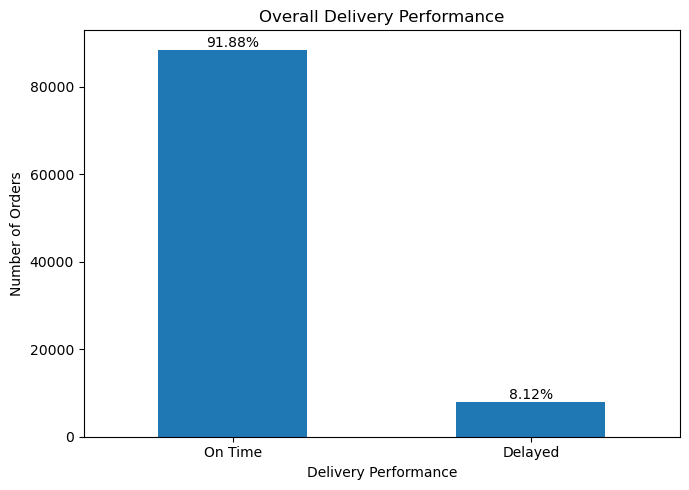

In [123]:
# Overall delivery performance

delivery_counts = clean_delivery_analysis['delivery_performance'].value_counts()

delivery_percent = (
    delivery_counts / delivery_counts.sum() * 100
)

plt.figure(figsize=(7, 5))
ax = delivery_counts.plot(kind='bar')

plt.title('Overall Delivery Performance')
plt.xlabel('Delivery Performance')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)

for i, (count, pct) in enumerate(zip(delivery_counts, delivery_percent)):
    ax.text(i, count, f'{pct:.2f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Monthly Delay Percentage

In [ ]:
# Monthly delay percentage

In [127]:
print(monthly_performance.dtypes)
print("\nIndex:")
print(monthly_performance.index)
print("\nDelayed % values:")
print(monthly_performance['Delayed %'])

delivery_performance
Delayed           int64
On Time           int64
Total Orders      int64
Delayed %       float64
dtype: object

Index:
PeriodIndex(['2016-09', '2016-10', '2016-12', '2017-01', '2017-02', '2017-03',
             '2017-04', '2017-05', '2017-06', '2017-07', '2017-08', '2017-09',
             '2017-10', '2017-11', '2017-12', '2018-01', '2018-02', '2018-03',
             '2018-04', '2018-05', '2018-06', '2018-07', '2018-08'],
            dtype='period[M]', name='purchase_month')

Delayed % values:
purchase_month
2016-09    100.00
2016-10      1.15
2016-12      0.00
2017-01      3.07
2017-02      3.21
2017-03      5.58
2017-04      7.86
2017-05      3.61
2017-06      3.86
2017-07      3.44
2017-08      3.32
2017-09      5.18
2017-10      5.29
2017-11     14.31
2017-12      8.38
2018-01      6.56
2018-02     15.99
2018-03     21.36
2018-04      5.32
2018-05      8.28
2018-06      1.36
2018-07      4.48
2018-08     10.47
Freq: M, Name: Delayed %, dtype: float64


In [134]:
monthly_filtered = monthly_performance[
    monthly_performance['Total Orders'] >= 100
]

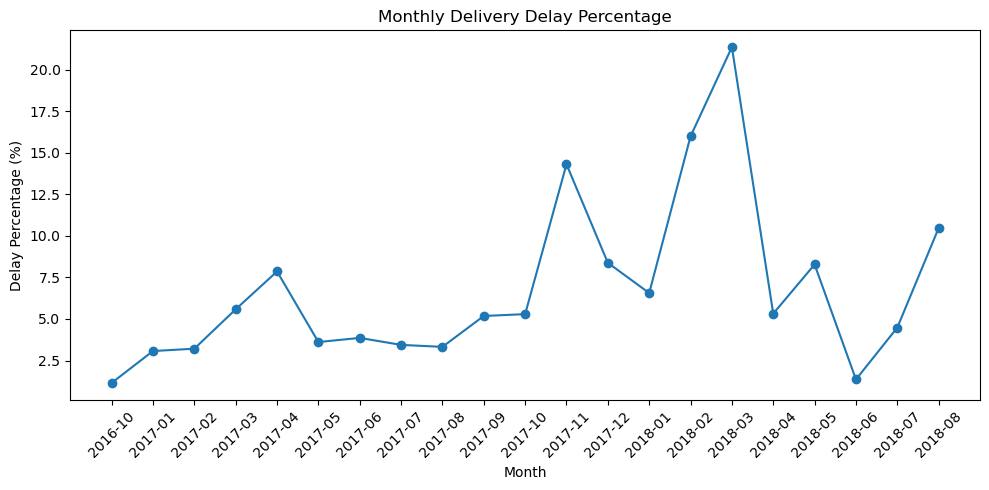

In [135]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_filtered.index.astype(str),
    monthly_filtered['Delayed %'].astype(float),
    marker='o'
)

plt.title('Monthly Delivery Delay Percentage')
plt.xlabel('Month')
plt.ylabel('Delay Percentage (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [136]:
print(monthly_performance[['Total Orders', 'Delayed', 'Delayed %']])

delivery_performance  Total Orders  Delayed  Delayed %
purchase_month                                        
2016-09                          1        1     100.00
2016-10                        261        3       1.15
2016-12                          1        0       0.00
2017-01                        749       23       3.07
2017-02                       1651       53       3.21
2017-03                       2545      142       5.58
2017-04                       2303      181       7.86
2017-05                       3544      128       3.61
2017-06                       3134      121       3.86
2017-07                       3861      133       3.44
2017-08                       4191      139       3.32
2017-09                       4149      215       5.18
2017-10                       4478      237       5.29
2017-11                       7288     1043      14.31
2017-12                       5513      462       8.38
2018-01                       7069      464       6.56
2018-02   

#### What we can say from this chart
- March 2018 has the highest delay rate at approximately 21.36%.
- February 2018 is also high at around 16%.
- November 2017 reached roughly 14.3%.
- June 2018 had the lowest delay rate at around 1.4%.
- There is a noticeable increase in delivery delays during late 2017 and early 2018.

### March 2018 state-wise delay percentage

In [137]:
# March 2018 state-wise delivery delay percentage

march_state = (
    march_2018
    .merge(
        customers[['customer_id', 'customer_state']],
        on='customer_id',
        how='left'
    )
    .groupby('customer_state')
    .agg(
        Total_Orders=('order_id', 'count'),
        Delayed_Orders=('delivery_performance', lambda x: (x == 'Delayed').sum())
    )
)

march_state['Delay %'] = (
    march_state['Delayed_Orders'] /
    march_state['Total_Orders'] * 100
)

# Keep states with at least 100 orders
march_state_filtered = (
    march_state[march_state['Total_Orders'] >= 100]
    .sort_values('Delay %', ascending=False)
    .head(10)
)

print(march_state_filtered)

                Total_Orders  Delayed_Orders    Delay %
customer_state                                         
ES                       133              59  44.360902
RJ                       864             319  36.921296
BA                       235              83  35.319149
SC                       247              58  23.481781
PE                       107              25  23.364486
MG                       856             199  23.247664
RS                       407              84  20.638821
DF                       147              30  20.408163
GO                       141              28  19.858156
PR                       369              56  15.176152


In [138]:
march_state['Total_Orders'] >= 100

customer_state
AC    False
AL    False
AM    False
AP    False
BA     True
CE    False
DF     True
ES     True
GO     True
MA    False
MG     True
MS    False
MT    False
PA    False
PB    False
PE     True
PI    False
PR     True
RJ     True
RN    False
RO    False
RR    False
RS     True
SC     True
SE    False
SP     True
TO    False
Name: Total_Orders, dtype: bool

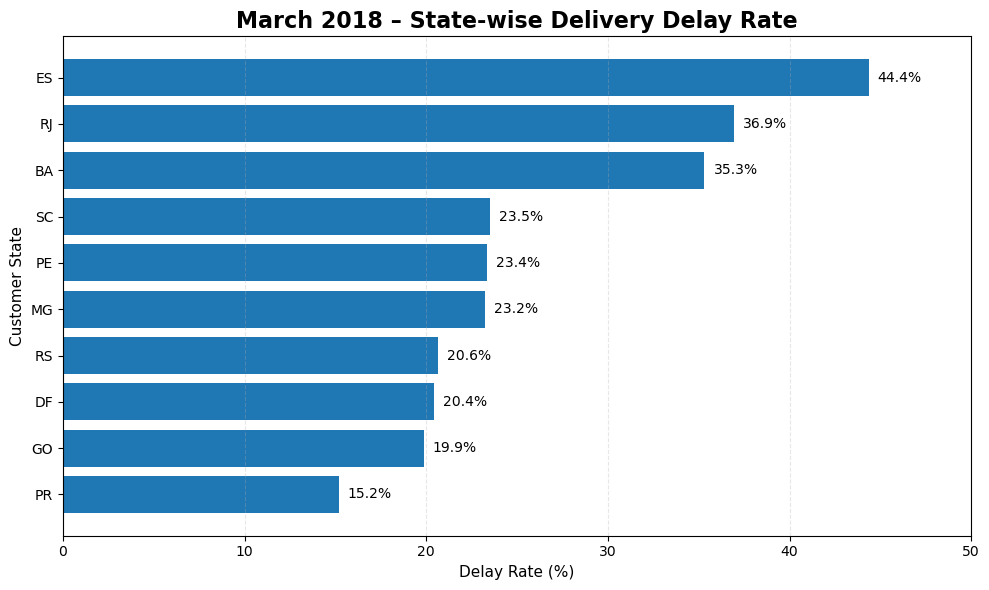

In [141]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

bars = plt.barh(
    march_state_filtered.index,
    march_state_filtered['Delay %']
)

# Highest delay at the top
plt.gca().invert_yaxis()

# Add percentage labels
for bar, value in zip(bars, march_state_filtered['Delay %']):
    plt.text(
        value + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{value:.1f}%',
        va='center',
        fontsize=10
    )

plt.title(
    'March 2018 – State-wise Delivery Delay Rate',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Delay Rate (%)', fontsize=11)
plt.ylabel('Customer State', fontsize=11)

plt.xlim(0, 50)
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

##### ES has the highest delay rate at 44.4%, followed by RJ at 36.9% and BA at 35.3%.

## Delivery Delay by Product Category

In [152]:
# Delivery performance by product category

category_performance = (
    clean_delivery_analysis
    .merge(
        items[['order_id', 'product_id']],
        on='order_id',
        how='left'
    )
    .merge(
        products[['product_id', 'product_category_name']],
        on='product_id',
        how='left'
    )
    .groupby('product_category_name')
    .agg(
        Total_Orders=('order_id', 'count'),
        Delayed_Orders=('delivery_performance', lambda x: (x == 'Delayed').sum())
    )
    .reset_index()
)

# Calculate delay percentage
category_performance['Delay %'] = (
    category_performance['Delayed_Orders']
    / category_performance['Total_Orders']
    * 100
)

# Keep categories with sufficient order volume
category_filtered = (
    category_performance[
        category_performance['Total_Orders'] >= 100
    ]
    .sort_values('Delay %', ascending=False)
)

print(category_filtered.head(10))

                product_category_name  Total_Orders  Delayed_Orders    Delay %
7                               audio           362              46  12.707182
39     fashion_underwear_e_moda_praia           127              16  12.598425
6                    artigos_de_natal           150              18  12.000000
49                    livros_tecnicos           261              29  11.111111
14                      casa_conforto           426              44  10.328638
23  construcao_ferramentas_iluminacao           301              30   9.966777
1                           alimentos           496              49   9.879032
30                        eletronicos          2724             265   9.728341
11                       beleza_saude          9447             857   9.071663
55                  moveis_escritorio          1667             149   8.938212


### Top 10 categories with the highest delay rate

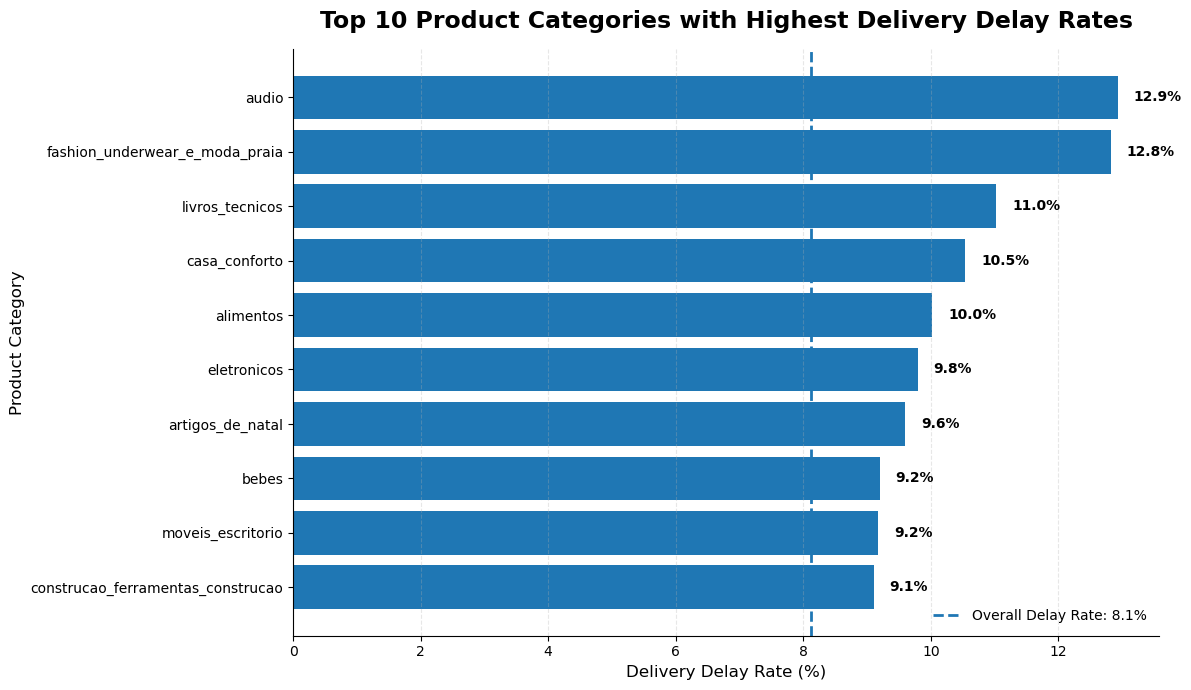

In [154]:
# Keep only the required columns
category_data = (
    clean_delivery_analysis[
        ['order_id', 'delivery_performance']
    ]
    .merge(
        items[['order_id', 'product_id']],
        on='order_id',
        how='left'
    )
    .merge(
        products[['product_id', 'product_category_name']],
        on='product_id',
        how='left'
    )
)

# Remove duplicate order-category combinations
category_data = category_data.drop_duplicates(
    subset=['order_id', 'product_category_name']
)

# Remove missing categories
category_data = category_data.dropna(
    subset=['product_category_name']
)

# Calculate category performance
category_performance = (
    category_data
    .groupby('product_category_name')
    .agg(
        Total_Orders=('order_id', 'nunique'),
        Delayed_Orders=(
            'delivery_performance',
            lambda x: (x == 'Delayed').sum()
        )
    )
    .reset_index()
)

# Calculate delay rate
category_performance['Delay %'] = (
    category_performance['Delayed_Orders']
    / category_performance['Total_Orders']
    * 100
)

# Keep categories with at least 100 orders
category_filtered = (
    category_performance[
        category_performance['Total_Orders'] >= 100
    ]
    .sort_values('Delay %', ascending=False)
)

# Top 10 categories
top_10 = category_filtered.head(10).sort_values('Delay %')

# Overall delay rate
overall_delay = (
    clean_delivery_analysis['delivery_performance']
    .eq('Delayed')
    .mean() * 100
)


fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    top_10['product_category_name'],
    top_10['Delay %']
)

# Overall benchmark
ax.axvline(
    overall_delay,
    linestyle='--',
    linewidth=2,
    label=f'Overall Delay Rate: {overall_delay:.1f}%'
)

# Add percentage labels
for bar in bars:
    width = bar.get_width()

    ax.text(
        width + 0.25,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.1f}%',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

# Title
ax.set_title(
    'Top 10 Product Categories with Highest Delivery Delay Rates',
    fontsize=17,
    fontweight='bold',
    pad=15
)

ax.set_xlabel(
    'Delivery Delay Rate (%)',
    fontsize=12
)

ax.set_ylabel(
    'Product Category',
    fontsize=12
)

# Clean presentation
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.3
)

ax.legend(
    loc='lower right',
    frameon=False
)

plt.tight_layout()
plt.show()

##### Audio and fashion-underwear categories have the highest delivery delay rates (~13%), significantly above the overall delay rate of 8.1%, indicating these categories should be prioritized for further logistics and seller-performance investigation.

### Delivery Time Distribution

In [157]:
# Delivery time distribution

delivery_distribution = (
    clean_delivery_analysis['delivery_time_days']
    .dropna()
)

bins = [-1, 2, 5, 10, 20, 30, float('inf')]
labels = ['0–2 days', '3–5 days', '6–10 days',
          '11–20 days', '21–30 days', '30+ days']

delivery_categories = pd.cut(
    delivery_distribution,
    bins=bins,
    labels=labels
)

delivery_counts = delivery_categories.value_counts().reindex(labels)

print("Delivery Time Categories:")
print(delivery_counts)

Delivery Time Categories:
delivery_time_days
0–2 days       1576
3–5 days      11797
6–10 days     32958
11–20 days    35730
21–30 days     9672
30+ days       4548
Name: count, dtype: int64


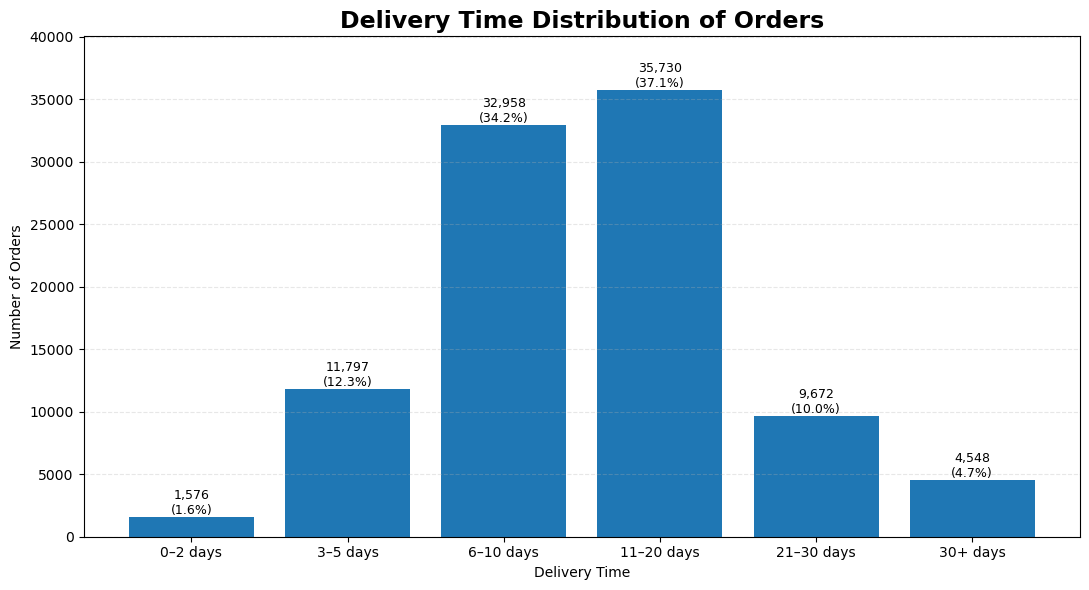

In [160]:
plt.figure(figsize=(11, 6))

bars = plt.bar(
    delivery_counts.index,
    delivery_counts.values
)

plt.title(
    'Delivery Time Distribution of Orders',
    fontsize=17,
    fontweight='bold'
)

plt.xlabel('Delivery Time')
plt.ylabel('Number of Orders')

# Add count + percentage labels
for bar, count, pct in zip(
    bars,
    delivery_counts,
    delivery_percent
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{count:,}\n({pct:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=9
    )

# Add extra space above the tallest bar
plt.ylim(0, delivery_counts.max() * 1.12)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()
plt.show()

##### Insight: 71.3% of orders were delivered within 6–20 days, while 14.8% took more than 20 days, highlighting a significant segment of slow deliveries.

## Estimated vs Actual Delivery Time

How accurately did the estimated delivery dates predict actual delivery time?

In [161]:
estimated_actual = clean_delivery_analysis[
    ['actual_delivery_days', 'estimated_delivery_days']
].dropna()

estimated_actual.describe()

,actual_delivery_days,estimated_delivery_days
count,96281.000000,96281.000000
mean,12.568101,23.737269
std,9.549581,8.755936
min,0.533414,2.008009
25%,6.775822,18.333125
50%,10.227187,23.232350
75%,15.732361,28.407708
max,209.628611,155.135463


In [162]:
print("Average Actual Delivery Time:",
      estimated_actual['actual_delivery_days'].mean())

print("Average Estimated Delivery Time:",
      estimated_actual['estimated_delivery_days'].mean())

print("Average Difference:",
      (
          estimated_actual['actual_delivery_days']
          - estimated_actual['estimated_delivery_days']
      ).mean())

Average Actual Delivery Time: 12.568100830896409
Average Estimated Delivery Time: 23.737269171747275
Average Difference: -11.169168340850874


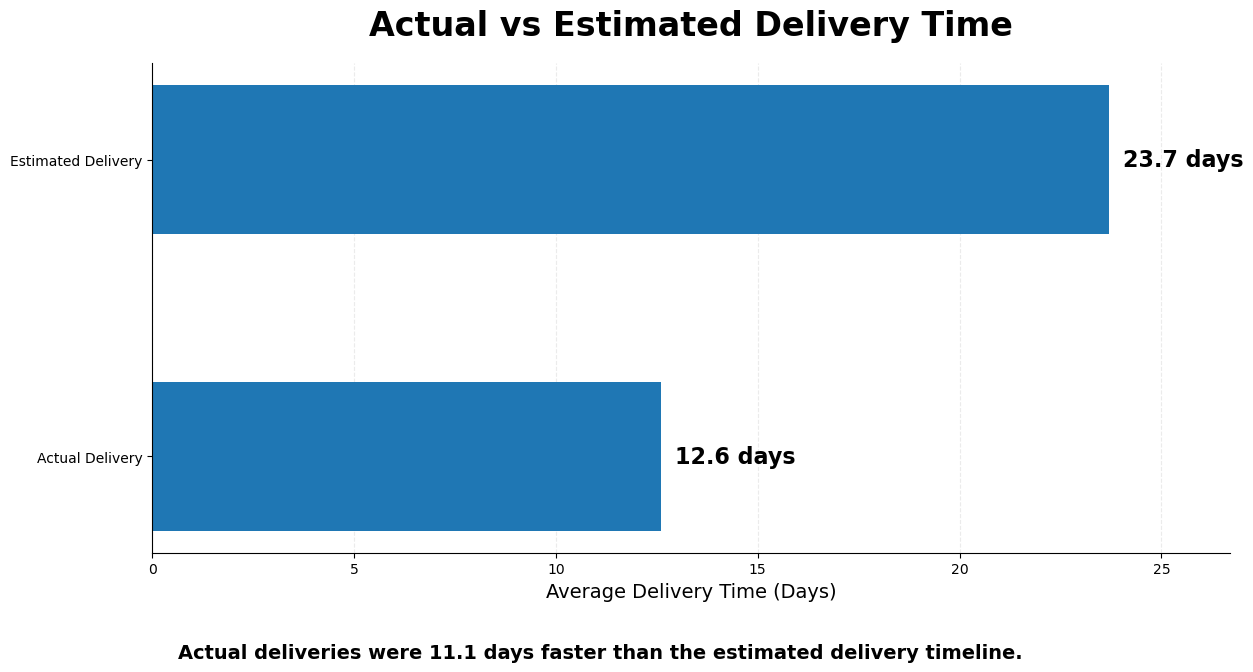

In [170]:
import matplotlib.pyplot as plt

# Values
actual_delivery = 12.6
estimated_delivery = 23.7
difference = estimated_delivery - actual_delivery

labels = ['Actual Delivery', 'Estimated Delivery']
values = [actual_delivery, estimated_delivery]

# Create chart
fig, ax = plt.subplots(figsize=(14, 7))

bars = ax.barh(
    labels,
    values,
    height=0.5
)

# Value labels
for bar, value in zip(bars, values):
    ax.text(
        value + 0.35,
        bar.get_y() + bar.get_height() / 2,
        f'{value:.1f} days',
        va='center',
        fontsize=16,
        fontweight='bold'
    )

# Title
ax.set_title(
    'Actual vs Estimated Delivery Time',
    fontsize=24,
    fontweight='bold',
    pad=20
)

# Axis labels
ax.set_xlabel(
    'Average Delivery Time (Days)',
    fontsize=14
)

# Grid
ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.25
)

ax.set_axisbelow(True)

# Give enough space on right for value labels
ax.set_xlim(0, estimated_delivery + 3)

# Remove unnecessary borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Insight at the BOTTOM
fig.text(
    0.5,
    0.03,
    f'Actual deliveries were {difference:.1f} days faster than the estimated delivery timeline.',
    ha='center',
    fontsize=14,
    fontweight='bold'
)

# Leave space at bottom for insight
plt.subplots_adjust(
    bottom=0.18,
    top=0.88,
    left=0.18,
    right=0.95
)

plt.show()

# Monthly Delivery Performance Trend

In [171]:
# Monthly delivery performance
monthly_performance = (
    clean_delivery_analysis
    .groupby(['purchase_month', 'delivery_performance'])
    .size()
    .unstack(fill_value=0)
)

monthly_performance

delivery_performance,Delayed,On Time
purchase_month,,
2016-09,1,0
2016-10,3,258
2016-12,0,1
2017-01,23,726
2017-02,53,1598
2017-03,142,2403
2017-04,181,2122
2017-05,128,3416
2017-06,121,3013


In [172]:
monthly_delay_rate = (
    clean_delivery_analysis
    .groupby('purchase_month')['delay_days']
    .apply(lambda x: (x > 0).mean() * 100)
    .reset_index(name='Delay Rate (%)')
)

monthly_delay_rate

,purchase_month,Delay Rate (%)
0,2016-09,100.000000
1,2016-10,1.149425
2,2016-12,0.000000
3,2017-01,3.070761
4,2017-02,3.210176
5,2017-03,5.579568
6,2017-04,7.859314
7,2017-05,3.611738
8,2017-06,3.860881
9,2017-07,3.444703


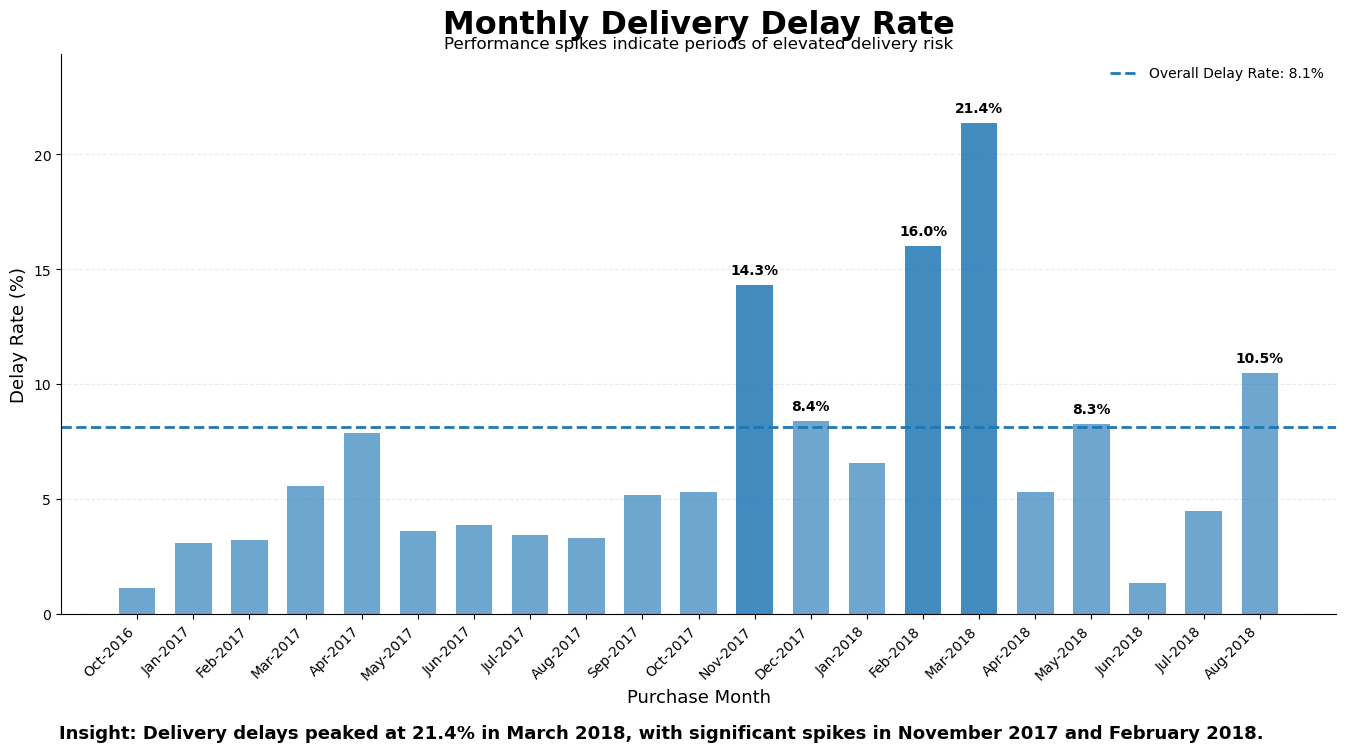

In [177]:
import matplotlib.pyplot as plt
import pandas as pd

# Copy data
monthly = monthly_delay_rate.copy()

# Convert Period to Timestamp
monthly['purchase_month'] = monthly['purchase_month'].dt.to_timestamp()

# Sort chronologically
monthly = monthly.sort_values('purchase_month')

# Calculate monthly order volume
monthly_orders = (
    clean_delivery_analysis
    .groupby('purchase_month')
    .size()
    .reset_index(name='Total Orders')
)

monthly_orders['purchase_month'] = (
    monthly_orders['purchase_month'].dt.to_timestamp()
)

# Merge order volume
monthly = monthly.merge(
    monthly_orders,
    on='purchase_month',
    how='left'
)

# Remove very low-volume months
monthly = monthly[monthly['Total Orders'] >= 100]

# Overall delay rate
overall_delay_rate = (
    (clean_delivery_analysis['delay_days'] > 0).mean() * 100
)

# Find highest-delay months
top_months = monthly.nlargest(3, 'Delay Rate (%)')

# -----------------------------
# Create Chart
# -----------------------------

fig, ax = plt.subplots(figsize=(15, 8))

bars = ax.bar(
    monthly['purchase_month'].dt.strftime('%b-%Y'),
    monthly['Delay Rate (%)'],
    width=0.65
)

# Highlight top 3 months
for bar, month, value in zip(
    bars,
    monthly['purchase_month'],
    monthly['Delay Rate (%)']
):
    if month in top_months['purchase_month'].values:
        bar.set_alpha(0.85)
    else:
        bar.set_alpha(0.65)

# Add labels only to important months
for bar, month, value in zip(
    bars,
    monthly['purchase_month'],
    monthly['Delay Rate (%)']
):
    if value >= overall_delay_rate or value == monthly['Delay Rate (%)'].max():

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.35,
            f'{value:.1f}%',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

# Overall benchmark
ax.axhline(
    overall_delay_rate,
    linestyle='--',
    linewidth=2,
    label=f'Overall Delay Rate: {overall_delay_rate:.1f}%'
)

# Title
ax.set_title(
    'Monthly Delivery Delay Rate',
    fontsize=23,
    fontweight='bold',
    pad=15
)

# Subtitle
ax.text(
    0.5,
    1.01,
    'Performance spikes indicate periods of elevated delivery risk',
    transform=ax.transAxes,
    ha='center',
    fontsize=12
)

# Axis labels
ax.set_xlabel(
    'Purchase Month',
    fontsize=13
)

ax.set_ylabel(
    'Delay Rate (%)',
    fontsize=13
)

# Grid
ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.25
)

ax.set_axisbelow(True)

# Rotate month labels
plt.xticks(
    rotation=45,
    ha='right'
)

# Give space above labels
ax.set_ylim(
    0,
    monthly['Delay Rate (%)'].max() + 3
)

# Legend
ax.legend(
    loc='upper right',
    frameon=False
)

# Remove unnecessary borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Insight at bottom
fig.text(
    0.5,
    0.025,
    'Insight: Delivery delays peaked at 21.4% in March 2018, '
    'with significant spikes in November 2017 and February 2018.',
    ha='center',
    fontsize=13,
    fontweight='bold'
)

# Layout
plt.subplots_adjust(
    bottom=0.18,
    top=0.88,
    left=0.10,
    right=0.95
)

plt.show()

# Carrier Performance

In [189]:
# Extreme delay summary

print("Total extreme delays (20+ days):", len(extreme_delays))

print("\nExtreme delay statistics:")
print(
    extreme_delays['delay_days'].describe()
)

print("\nDelivery performance:")
print(
    extreme_delays['delivery_performance'].value_counts()
)

print("\nAverage actual delivery time:")
print(
    extreme_delays['actual_delivery_days'].mean()
)

print("\nAverage estimated delivery time:")
print(
    extreme_delays['estimated_delivery_days'].mean()
)

Total extreme delays (20+ days): 884

Extreme delay statistics:
count    884.000000
mean      36.964692
std       26.037228
min       20.013322
25%       22.830773
50%       28.484797
75%       37.909916
max      188.975081
Name: delay_days, dtype: float64

Delivery performance:
delivery_performance
Delayed    884
Name: count, dtype: int64

Average actual delivery time:
61.86085616725323

Average estimated delivery time:
24.89616442517178


In [190]:
extreme_monthly = (
    extreme_delays
    .groupby('purchase_month')
    .size()
    .sort_values(ascending=False)
)

print("Extreme delays by month:")
print(extreme_monthly)

Extreme delays by month:
purchase_month
2018-03    179
2018-02    178
2017-11    147
2018-01     66
2017-12     48
2018-04     37
2017-03     28
2017-07     23
2017-10     21
2018-07     21
2017-09     19
2017-06     17
2017-05     16
2018-05     16
2018-06     15
2017-04     14
2017-02     13
2017-08     11
2017-01      9
2018-08      5
2016-09      1
Freq: M, dtype: int64


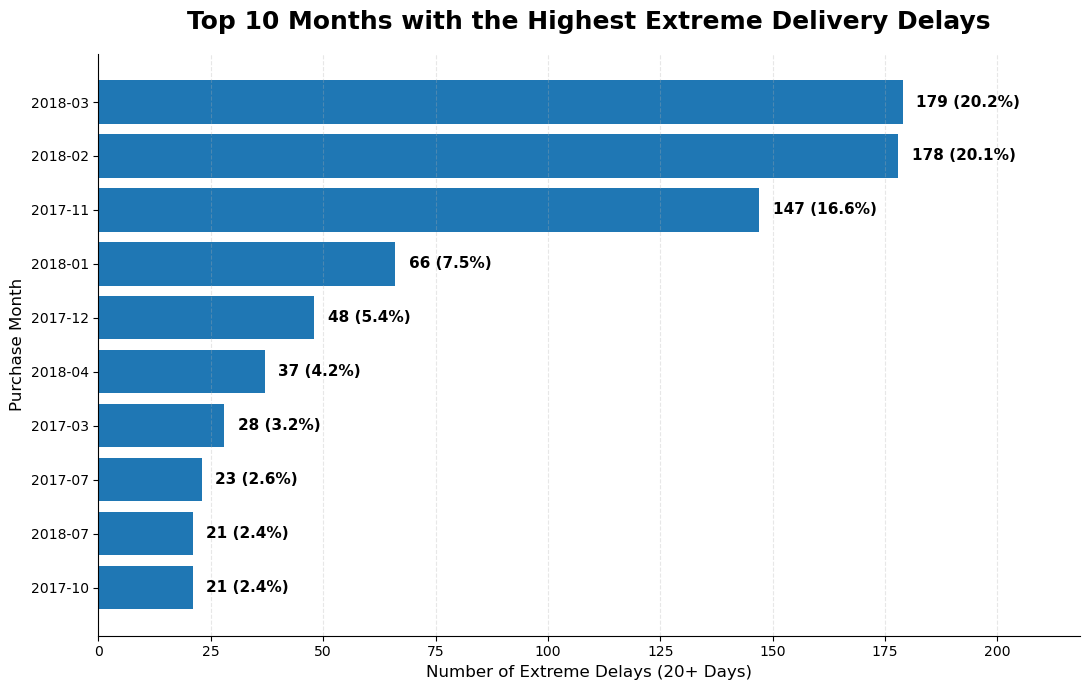

In [191]:
# Top 10 months with the highest number of extreme delays

extreme_monthly = (
    extreme_delays
    .groupby('purchase_month')
    .size()
    .sort_values(ascending=False)
    .head(10)
    .sort_values(ascending=True)
)

# Calculate percentage of all extreme delays
total_extreme = len(extreme_delays)

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    extreme_monthly.index.astype(str),
    extreme_monthly.values
)

# Add labels
for bar in bars:
    width = bar.get_width()
    percentage = (width / total_extreme) * 100
    
    ax.text(
        width + 3,
        bar.get_y() + bar.get_height() / 2,
        f'{int(width):,} ({percentage:.1f}%)',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

# Title
ax.set_title(
    'Top 10 Months with the Highest Extreme Delivery Delays',
    fontsize=18,
    fontweight='bold',
    pad=18
)

ax.set_xlabel(
    'Number of Extreme Delays (20+ Days)',
    fontsize=12
)

ax.set_ylabel(
    'Purchase Month',
    fontsize=12
)

# Give labels enough space
ax.set_xlim(0, extreme_monthly.max() * 1.22)

# Grid
ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.3
)

# Clean appearance
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

##### Extreme delivery delays were highly concentrated in a few months, with March 2018, February 2018, and November 2017 accounting for 57% of all 20+ day delays.

# Delivery Delays by Customer State

In [195]:
# Count extreme delays by customer state
state_extreme_delays = (
    extreme_delays_state
    .groupby('customer_state')
    .size()
    .reset_index(name='Extreme Delays')
    .sort_values('Extreme Delays', ascending=False)
)

# Calculate percentage of all extreme delays
state_extreme_delays['Percentage'] = (
    state_extreme_delays['Extreme Delays']
    / state_extreme_delays['Extreme Delays'].sum()
    * 100
)

# Top 10 states
top_states = state_extreme_delays.head(10)

top_states

,customer_state,Extreme Delays,Percentage
18,RJ,357,40.384615
24,SP,145,16.402715
4,BA,47,5.316742
10,MG,46,5.203620
5,CE,40,4.524887
21,RS,34,3.846154
15,PE,27,3.054299
7,ES,27,3.054299
8,GO,20,2.262443
22,SC,19,2.149321


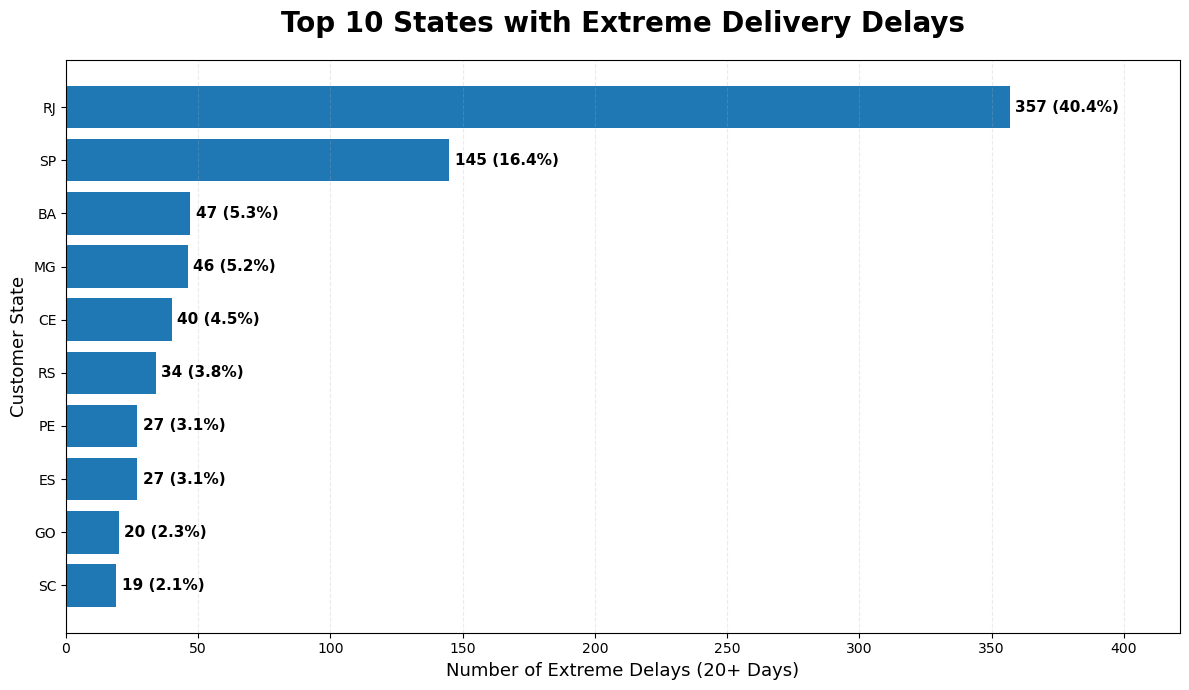

In [196]:
plt.figure(figsize=(12, 7))

bars = plt.barh(
    top_states['customer_state'][::-1],
    top_states['Extreme Delays'][::-1]
)

# Add value + percentage labels
for bar, count, pct in zip(
    bars,
    top_states['Extreme Delays'][::-1],
    top_states['Percentage'][::-1]
):
    plt.text(
        bar.get_width() + 2,
        bar.get_y() + bar.get_height() / 2,
        f'{count} ({pct:.1f}%)',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title(
    'Top 10 States with Extreme Delivery Delays',
    fontsize=20,
    fontweight='bold',
    pad=20
)

plt.xlabel(
    'Number of Extreme Delays (20+ Days)',
    fontsize=13
)

plt.ylabel(
    'Customer State',
    fontsize=13
)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.25
)

# Prevent labels from touching the border
plt.xlim(
    0,
    top_states['Extreme Delays'].max() * 1.18
)

plt.tight_layout()
plt.show()

# State-wise Delay Rate

In [198]:
# Add customer state to carrier_analysis
carrier_state_analysis = carrier_analysis.merge(
    customers[['customer_id', 'customer_state']],
    on='customer_id',
    how='left'
)

print(carrier_state_analysis.shape)
print(carrier_state_analysis['customer_state'].isna().sum())

(96281, 18)
0


In [199]:
state_performance = (
    carrier_state_analysis
    .groupby('customer_state')['delivery_performance']
    .value_counts()
    .unstack(fill_value=0)
    .reset_index()
)

# Total orders
state_performance['Total Orders'] = (
    state_performance.get('Delayed', 0) +
    state_performance.get('On Time', 0)
)

# Delay rate
state_performance['Delay Rate (%)'] = (
    state_performance.get('Delayed', 0)
    / state_performance['Total Orders']
    * 100
)

# Only states with at least 500 orders
state_performance_filtered = (
    state_performance[
        state_performance['Total Orders'] >= 500
    ]
    .sort_values('Delay Rate (%)', ascending=False)
)

state_performance_filtered.head(10)

delivery_performance,customer_state,Delayed,On Time,Total Orders,Delay Rate (%)
9,MA,141,573,714,19.747899
5,CE,196,1082,1278,15.336463
4,BA,456,2796,3252,14.022140
18,RJ,1664,10666,12330,13.495539
13,PA,117,828,945,12.380952
7,ES,244,1745,1989,12.267471
11,MS,81,618,699,11.587983
14,PB,57,460,517,11.025145
15,PE,172,1420,1592,10.804020
23,SC,346,3188,3534,9.790606


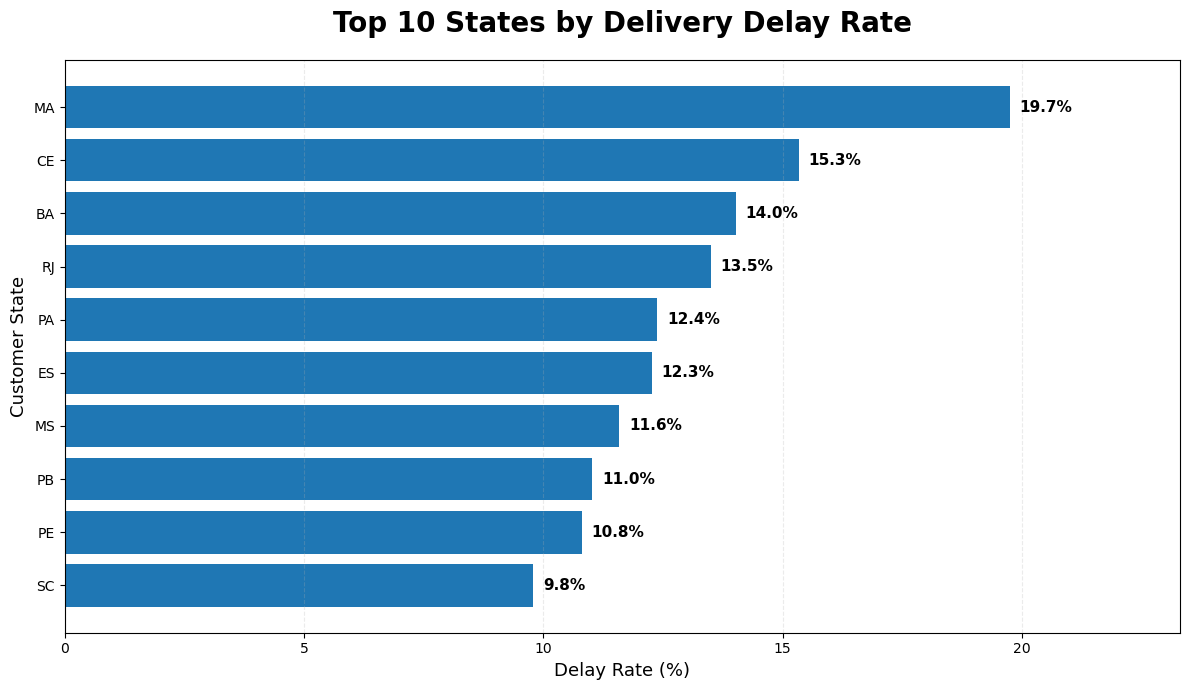

In [200]:
import matplotlib.pyplot as plt

top_states_delay = state_performance_filtered.head(10).copy()

plt.figure(figsize=(12, 7))

bars = plt.barh(
    top_states_delay['customer_state'][::-1],
    top_states_delay['Delay Rate (%)'][::-1]
)

# Add labels
for bar, rate in zip(
    bars,
    top_states_delay['Delay Rate (%)'][::-1]
):
    plt.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f'{rate:.1f}%',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title(
    'Top 10 States by Delivery Delay Rate',
    fontsize=20,
    fontweight='bold',
    pad=20
)

plt.xlabel(
    'Delay Rate (%)',
    fontsize=13
)

plt.ylabel(
    'Customer State',
    fontsize=13
)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.25
)

# Prevent value labels from touching the border
plt.xlim(
    0,
    top_states_delay['Delay Rate (%)'].max() * 1.18
)

plt.tight_layout()
plt.show()

##### Maranhão (MA) has the highest delay rate at 19.7%, indicating significant state-level delivery performance differences.

# Product Category-wise Delivery Performance

In [201]:
category_performance

,product_category_name,Total_Orders,Delayed_Orders,Delay %
0,agro_industria_e_comercio,177,9,5.084746
1,alimentos,439,44,10.022779
2,alimentos_bebidas,221,14,6.334842
3,artes,195,15,7.692308
4,artes_e_artesanato,23,2,8.695652
...,...,...,...,...
68,sinalizacao_e_seguranca,138,8,5.797101
69,tablets_impressao_imagem,79,5,6.329114
70,telefonia,4088,349,8.537182
71,telefonia_fixa,212,11,5.188679


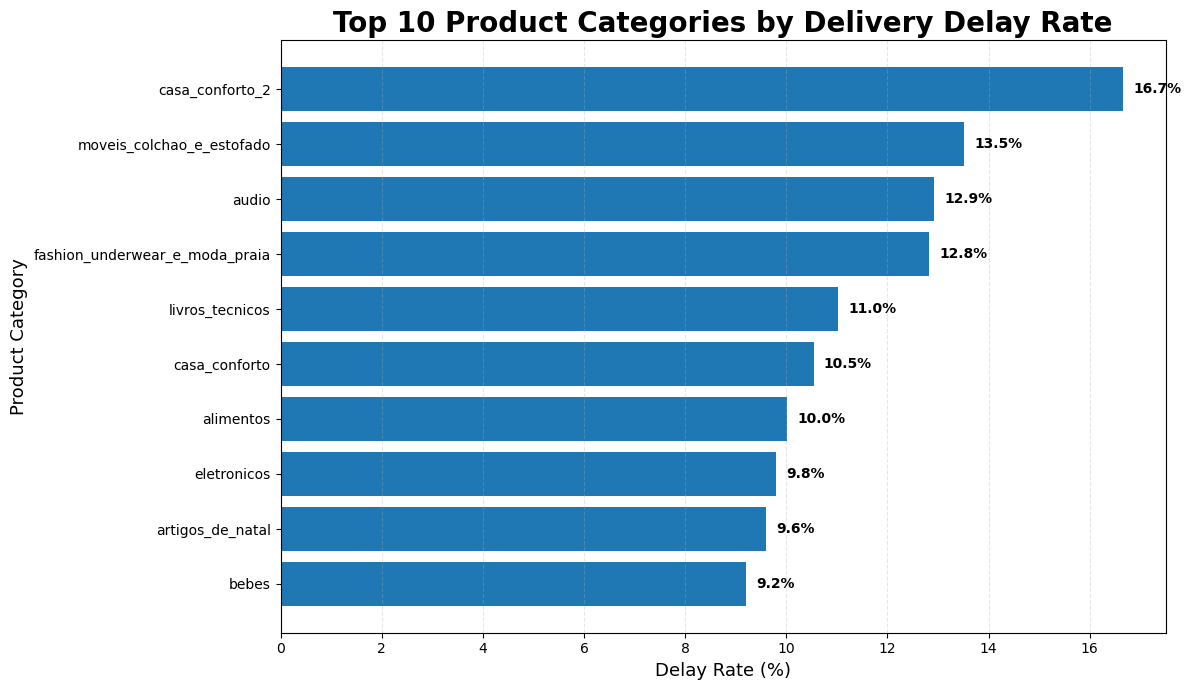

In [202]:
# Top 10 product categories by delay rate
top_10_categories = (
    category_performance
    .sort_values('Delay %', ascending=False)
    .head(10)
    .copy()
)

# Plot
plt.figure(figsize=(12, 7))

bars = plt.barh(
    top_10_categories['product_category_name'],
    top_10_categories['Delay %']
)

# Highest delay at the top
plt.gca().invert_yaxis()

# Add percentage labels
for bar, value in zip(bars, top_10_categories['Delay %']):
    plt.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f'{value:.1f}%',
        va='center',
        fontweight='bold'
    )

plt.title(
    'Top 10 Product Categories by Delivery Delay Rate',
    fontsize=20,
    fontweight='bold'
)

plt.xlabel('Delay Rate (%)', fontsize=13)
plt.ylabel('Product Category', fontsize=13)

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

### Final Business Insights
#### - 91.88% of orders were delivered on time, while 8.12% experienced delays, indicating strong overall delivery performance with a measurable delay segment.

- #### Actual deliveries averaged 12.57 days compared with an estimated 23.74 days, meaning orders were delivered 11.17 days earlier than the estimated timeline on average.

- #### March 2018 recorded the highest overall delay rate at approximately 21.36%, significantly above the overall delay rate of 8.12%, indicating a period of elevated delivery risk.

- #### 884 orders experienced extreme delays of 20+ days, with an average extreme delay of approximately 37 days and a maximum delay of nearly 189 days.

- #### March 2018, February 2018, and November 2017 accounted for approximately 57% of all extreme delays, showing that severe delivery failures were highly concentrated in specific periods.

- #### Maranhão (MA) recorded the highest state-level delay rate at 19.7%, more than twice the overall delay rate, highlighting a potential regional logistics bottleneck.

- #### The casa_conforto_2 product category recorded the highest delay rate at 16.7%, indicating that certain product categories may require additional logistics or fulfillment attention.